# Laboratorio 4, Parte 2, ejercicios 4 y 5 (entrenamiento y evaluación de modelos)

Este notebook retoma la preparación de datos documentada en `data_prep.ipynb` (ejercicios 1–3: integridad de fuentes, limpieza, variable respuesta y selección de predictores) y reutiliza el mismo pipeline reproducible (`preparar_ml.py` / `modelar_ml.py`). La celda de preparación del entorno se repite aquí porque cada notebook corre en su propio kernel; gracias a `reutilizar=True`, si el pipeline ya se ejecutó antes no se recalcula.

## 0. Preparación del entorno


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def localizar_proyecto(inicio=None):
    inicio = Path(inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if candidato.name == "l04_analisis_geoespacial" and (candidato / "data").exists():
            return candidato
        anidado = candidato / "l04_analisis_geoespacial"
        if (anidado / "data").exists():
            return anidado
    raise FileNotFoundError("No se encontró l04_analisis_geoespacial.")


PROJECT_DIR = localizar_proyecto()
SRC_DIR = PROJECT_DIR / "parte_2" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preparar_ml import (
    CRS_ANALISIS,
    PREDICTORES_BASE,
    UMBRAL_ALERTA_CHL,
    VARIABLES_PROHIBIDAS,
    auditar_predictores,
    ejecutar_pipeline,
    inventariar_escenas,
)

OUTPUT_DIR = PROJECT_DIR / "parte_2" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

resultado = ejecutar_pipeline(PROJECT_DIR, reutilizar=True)
manifest = resultado["manifest"]
print(f"Proyecto: {PROJECT_DIR}")
print(f"Dataset: {resultado['dataset_dir']}")
print(f"Versión del pipeline: {manifest['pipeline_version']}")


Proyecto: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial
Dataset: C:\Users\richi\Documents\2026_S2_Local\Data_Science\Data-Science\l04_analisis_geoespacial\parte_2\data\processed\dataset_ml
Versión del pipeline: 4


# 4. Construcción de modelos de Machine Learning

## 4.1–4.2 Modelos y división convencional 70/30

Se comparan tres familias: **Regresión Logística**, **Random Forest** y **XGBoost**. XGBoost es una implementación optimizada de *gradient boosting*; por tanto, cumple el requisito de Gradient Boosting o XGBoost del enunciado.

Para que el experimento sea reproducible y computacionalmente viable, se toma una muestra aleatoria **proporcional por lago y fecha de 600,000 observaciones** del dataset limpio completo. Esta muestra conserva la prevalencia global aproximada de la clase positiva. Se realiza una única división aleatoria estratificada:

- 70 % entrenamiento: 420,000 observaciones.
- 30 % prueba: 180,000 observaciones.
- `random_state=42` y estratificación por `alta_cyano`.

Los tres modelos reciben exactamente las mismas filas de entrenamiento y prueba. El conjunto de prueba no participa en la selección de hiperparámetros ni del umbral operativo.


In [2]:
from modelar_ml import (
    CONFIGURACIONES,
    PREDICTORAS,
    RANDOM_STATE,
    ejecutar_modelos,
)
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

resultado_modelos = ejecutar_modelos(PROJECT_DIR, reutilizar=True)
manifest_modelos = resultado_modelos["manifest_data"]
metricas_05 = pd.read_csv(resultado_modelos["metricas_05"])
metricas_operativas = pd.read_csv(resultado_modelos["metricas_operativas"])
busqueda = pd.read_csv(resultado_modelos["busqueda"])
predicciones_test = pd.read_parquet(resultado_modelos["predicciones"])

resumen_split = pd.DataFrame({
    "particion": ["Entrenamiento", "Prueba"],
    "observaciones": [manifest_modelos["train_n"], manifest_modelos["test_n"]],
    "porcentaje": [70.0, 30.0],
    "positivos": [manifest_modelos["positivos_train"], manifest_modelos["positivos_test"]],
})
display(resumen_split)
print(f"Prevalencia positiva en la muestra: {100 * manifest_modelos['prevalencia_muestra']:.3f}%")
print(f"Huella SHA-256 del test común: {manifest_modelos['test_sha256']}")

assert manifest_modelos["train_n"] == 420_000
assert manifest_modelos["test_n"] == 180_000
assert manifest_modelos["predictores"] == PREDICTORAS


,particion,observaciones,porcentaje,positivos
0,Entrenamiento,420000,70.0,4213
1,Prueba,180000,30.0,1806


Prevalencia positiva en la muestra: 1.003%
Huella SHA-256 del test común: c76dcdc95aab3d65e25912e353692fafdd2b685d9bc98a6f319258cc7b8b359c


### Preprocesamiento y desbalance

- **Regresión Logística:** estandarización de variables numéricas, codificación *one-hot* de `lago` y `satelite`, regularización L2 y `class_weight="balanced"`.
- **Random Forest:** codificación *one-hot*, `class_weight="balanced_subsample"` y paralelización de árboles.
- **XGBoost:** codificación *one-hot*, árboles de *gradient boosting* con el método `hist` y `scale_pos_weight=98.7` para compensar la razón aproximada de 99 negativos por positivo.

Los pesos de clase se calculan únicamente con las frecuencias del entrenamiento. No se sobremuestrea el test ni se altera su prevalencia.


## 4.3 Ajuste de hiperparámetros

El 70 % de entrenamiento se divide internamente en 80 % ajuste y 20 % validación, siempre de forma estratificada. El criterio principal de selección es **PR-AUC** en validación, por ser más informativo con una clase positiva cercana al 1 %; F2 se usa como desempate.

Valores evaluados:

- **Regresión Logística:** `C ∈ {0.1, 1, 10}`. Valores menores implican mayor regularización.
- **Random Forest:** 160–240 árboles, profundidad máxima 14, 20 o ilimitada, `min_samples_leaf ∈ {3, 5, 10}` y `max_features ∈ {sqrt, 0.7}`.
- **XGBoost:** 220–300 árboles, `max_depth ∈ {4, 5, 6}`, `learning_rate ∈ {0.05, 0.08}`, `min_child_weight ∈ {2, 3, 5}`, `subsample ∈ {0.85, 0.90}` y `colsample_bytree ∈ {0.80, 0.85, 0.90}`.

Después de seleccionar la configuración, cada modelo se vuelve a entrenar con todo el 70 %. Además, sobre la validación interna se escoge un umbral que maximiza **F2**, métrica que da cuatro veces más peso al *recall* que a la precisión.


In [3]:
columnas_busqueda = [
    "modelo", "configuracion", "parametros", "pr_auc_validacion",
    "roc_auc_validacion", "f2_validacion", "umbral_f2_validacion",
    "segundos_ajuste",
]
display(busqueda[columnas_busqueda].sort_values(["modelo", "configuracion"]))

elegidos = pd.DataFrame([
    {
        "modelo": modelo,
        "parametros_elegidos": parametros,
        "umbral_operativo": manifest_modelos["umbrales_operativos"][modelo],
    }
    for modelo, parametros in manifest_modelos["parametros_elegidos"].items()
])
display(elegidos)


,modelo,configuracion,parametros,pr_auc_validacion,roc_auc_validacion,f2_validacion,umbral_f2_validacion,segundos_ajuste
3,Random Forest,1,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""min...",0.953645,0.999397,0.914087,0.554242,18.471187
4,Random Forest,2,"{""max_depth"": 20, ""max_features"": ""sqrt"", ""min...",0.960689,0.997754,0.926941,0.429184,27.472221
5,Random Forest,3,"{""max_depth"": null, ""max_features"": 0.7, ""min_...",0.958454,0.998329,0.922592,0.515439,46.323195
0,Regresión Logística,1,"{""C"": 0.1}",0.822251,0.996432,0.859580,0.948454,1.919530
1,Regresión Logística,2,"{""C"": 1.0}",0.822452,0.996425,0.860215,0.950956,1.715839
2,Regresión Logística,3,"{""C"": 10.0}",0.822469,0.996416,0.859838,0.951581,1.688452
6,XGBoost,1,"{""colsample_bytree"": 0.85, ""learning_rate"": 0....",0.919704,0.998953,0.897065,0.925006,3.371439
7,XGBoost,2,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.950586,0.999310,0.923567,0.922564,4.917332
8,XGBoost,3,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.961273,0.999456,0.926807,0.817227,5.860304


,modelo,parametros_elegidos,umbral_operativo
0,Regresión Logística,{'C': 10.0},0.951581
1,Random Forest,"{'n_estimators': 240, 'max_depth': 20, 'min_sa...",0.429184
2,XGBoost,"{'n_estimators': 260, 'max_depth': 6, 'learnin...",0.817227


## 4.4 Conjunto de prueba común

La huella SHA-256 mostrada arriba identifica las 180,000 observaciones de prueba mediante lago, fecha, fila y columna. Las probabilidades de los tres modelos se almacenan junto a esos mismos identificadores, lo que impide comparar accidentalmente métricas calculadas sobre conjuntos diferentes.


# 5. Evaluación de los modelos

## 5.1 Métricas y matrices de confusión

Se reportan las métricas solicitadas con el umbral convencional de 0.5. Debido al desbalance, también se añaden PR-AUC, F2, *balanced accuracy* y especificidad. Posteriormente se presenta la evaluación con el umbral operativo elegido exclusivamente en validación.


In [4]:
columnas_metricas = [
    "modelo", "umbral", "accuracy", "precision", "recall", "f1", "f2",
    "roc_auc", "pr_auc", "balanced_accuracy", "specificity", "tn", "fp", "fn", "tp",
]
print("Métricas con umbral convencional 0.5")
display(metricas_05[columnas_metricas].style.format({c: "{:.4f}" for c in columnas_metricas[1:11]}))

print("Métricas con umbral operativo seleccionado en validación")
display(metricas_operativas[columnas_metricas].style.format({c: "{:.4f}" for c in columnas_metricas[1:11]}))

metricas_05.to_csv(OUTPUT_DIR / "05_metricas_modelos_umbral_05.csv", index=False)
metricas_operativas.to_csv(OUTPUT_DIR / "05_metricas_modelos_umbral_operativo.csv", index=False)


Métricas con umbral convencional 0.5


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Regresión Logística,0.5000,0.9807,0.3408,0.9900,0.5070,0.7169,0.9978,0.8213,0.9853,0.9806,174735,3459,18,1788
1,Random Forest,0.5000,0.9977,0.8310,0.9662,0.8935,0.9358,0.9996,0.9667,0.9821,0.9980,177839,355,61,1745
2,XGBoost,0.5000,0.9956,0.6957,0.9911,0.8175,0.9135,0.9996,0.9592,0.9934,0.9956,177411,783,16,1790


Métricas con umbral operativo seleccionado en validación


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Regresión Logística,0.9516,0.9943,0.6530,0.9203,0.7640,0.8507,0.9978,0.8213,0.9577,0.9950,177311,883,144,1662
1,Random Forest,0.4292,0.9974,0.8044,0.9745,0.8813,0.9350,0.9996,0.9667,0.9861,0.9976,177766,428,46,1760
2,XGBoost,0.8172,0.9967,0.7626,0.9767,0.8565,0.9248,0.9996,0.9592,0.9868,0.9969,177645,549,42,1764


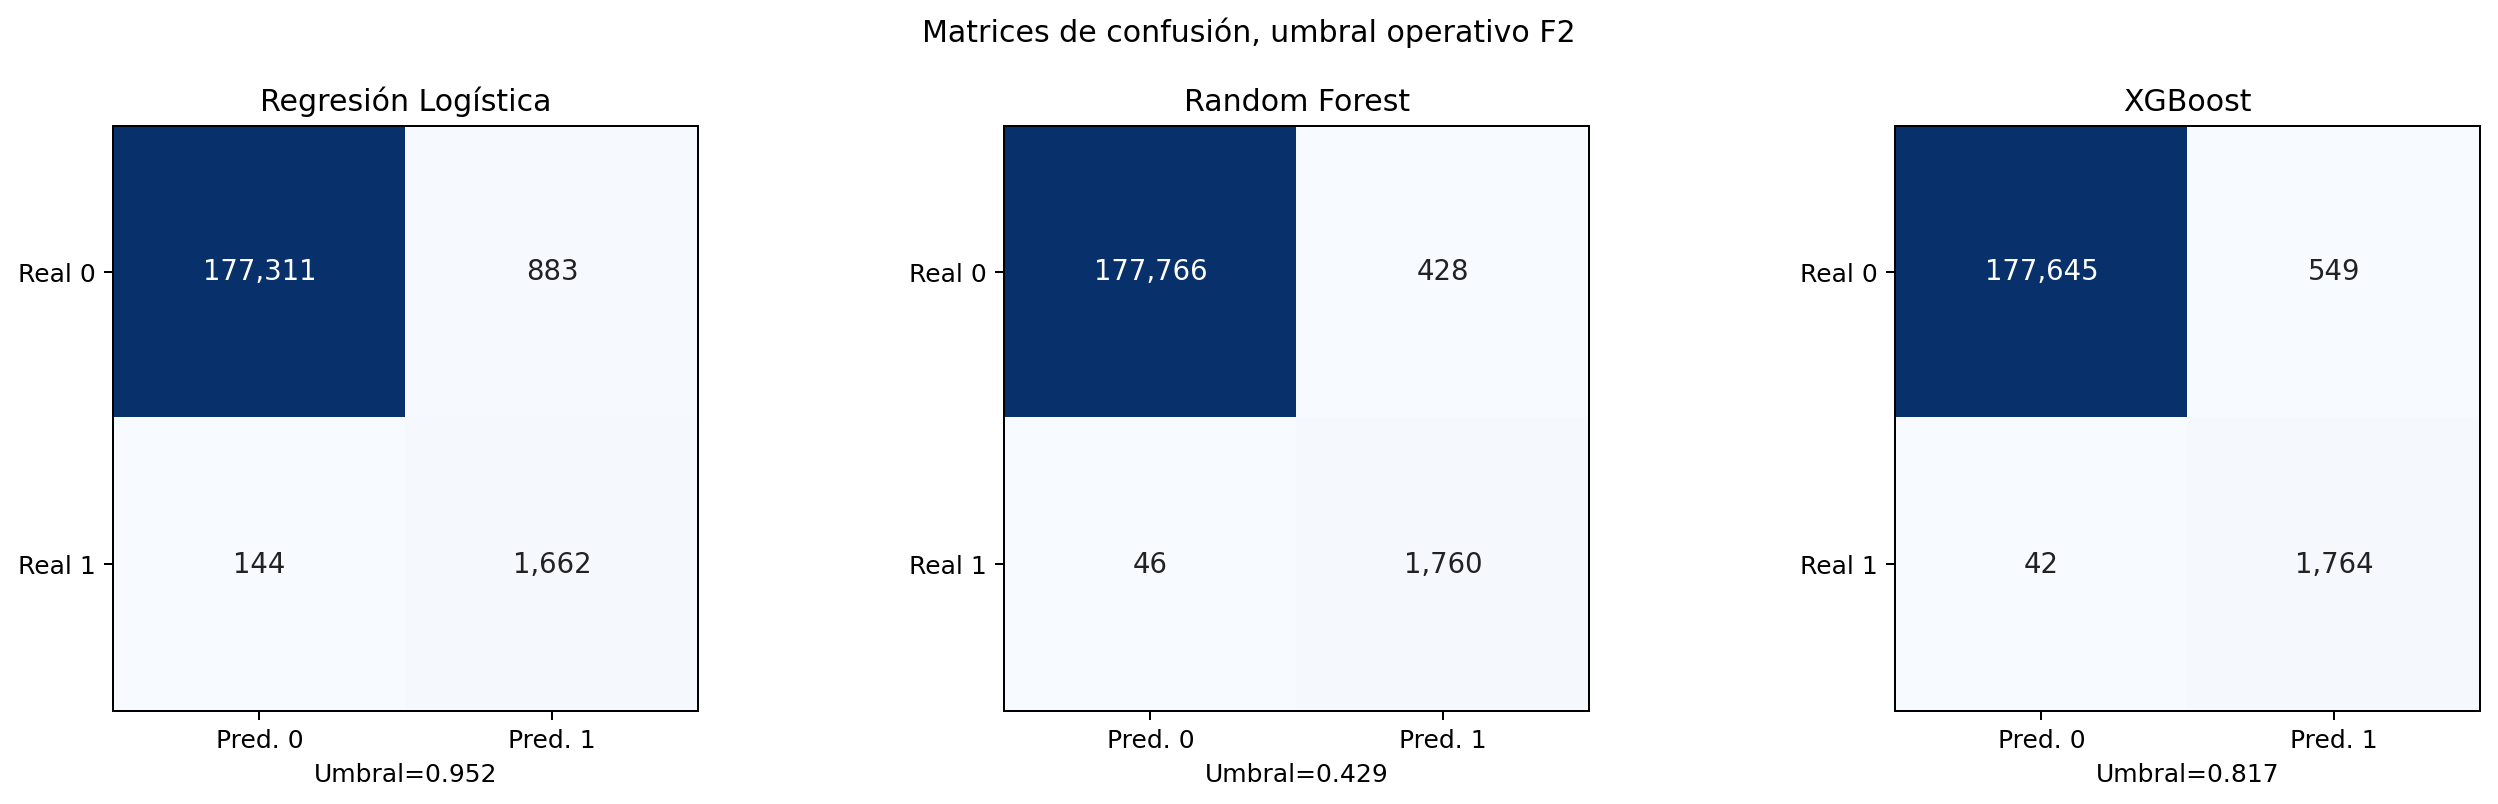

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, fila in zip(axes, metricas_operativas.itertuples(index=False)):
    matriz = np.array([[fila.tn, fila.fp], [fila.fn, fila.tp]])
    imagen = ax.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "#222222"
            ax.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1], ["Pred. 0", "Pred. 1"])
    ax.set_yticks([0, 1], ["Real 0", "Real 1"])
    ax.set_title(fila.modelo)
    ax.set_xlabel(f"Umbral={fila.umbral:.3f}")
fig.suptitle("Matrices de confusión, umbral operativo F2")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_matrices_confusion.png", dpi=180, bbox_inches="tight")
plt.show()


### Lectura de las matrices de confusión

Cada fila corresponde a la clase real y cada columna a la predicción. La celda superior izquierda concentra los verdaderos negativos; es muy grande porque solo el 1.003 % del test corresponde a presencia elevada. Por ello no basta con mirar la intensidad de color ni la *accuracy*.

Con Random Forest, de 1,806 píxeles con alta presencia real, 1,760 se identifican correctamente y 46 no se detectan: `recall = 1,760 / 1,806 = 97.5 %`. Sus 428 falsos positivos equivalen a aproximadamente 0.24 % de los 178,194 píxeles realmente negativos. Esta combinación es la más favorable para vigilancia: conserva una tasa muy alta de detección sin convertir una gran proporción del lago en alerta. XGBoost deja 42 falsos negativos y produce 549 falsas alertas; la regresión logística deja 144 y produce 883 con sus respectivos umbrales operativos.

Las matrices se muestran con los umbrales operativos seleccionados mediante F2, no con 0.5. Por eso los umbrales son distintos entre modelos y las matrices representan el escenario de decisión ambiental, no solo una clasificación convencional.


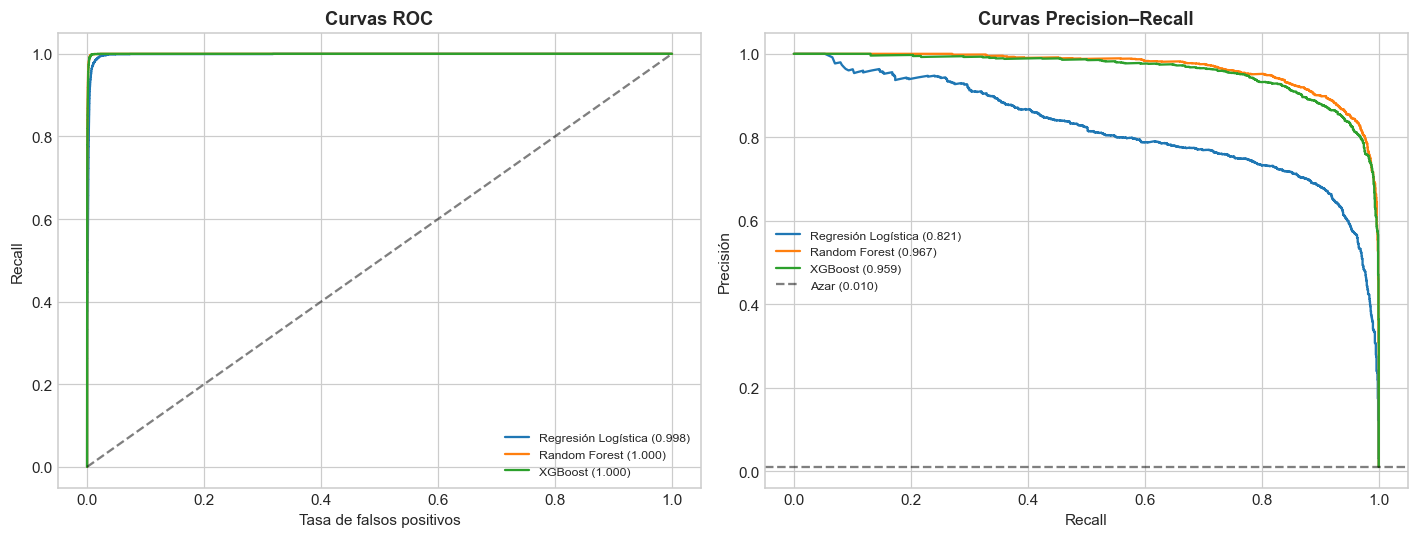

In [6]:
slugs = {
    "Regresión Logística": "regresion_logística",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
}
y_test = predicciones_test["alta_cyano"].to_numpy()
prevalencia_test = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for modelo, slug in slugs.items():
    prob = predicciones_test[f"prob_{slug}"].to_numpy()
    fpr, tpr, _ = roc_curve(y_test, prob)
    precision_pr, recall_pr, _ = precision_recall_curve(y_test, prob)
    roc_auc = metricas_operativas.loc[metricas_operativas["modelo"] == modelo, "roc_auc"].iloc[0]
    pr_auc = metricas_operativas.loc[metricas_operativas["modelo"] == modelo, "pr_auc"].iloc[0]
    axes[0].plot(fpr, tpr, label=f"{modelo} ({roc_auc:.3f})")
    axes[1].plot(recall_pr, precision_pr, label=f"{modelo} ({pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Recall", title="Curvas ROC")
axes[1].axhline(prevalencia_test, color="k", linestyle="--", alpha=0.5, label=f"Azar ({prevalencia_test:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precisión", title="Curvas Precision–Recall")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "07_curvas_roc_pr.png", dpi=180, bbox_inches="tight")
plt.show()


### Lectura de ROC y Precision–Recall

La diagonal de la curva ROC representa un clasificador al azar. Las tres curvas se acercan a la esquina superior izquierda, lo que indica una alta capacidad para ordenar los píxeles positivos por encima de los negativos en distintos umbrales. Los valores mostrados como `1.000` para Random Forest y XGBoost son redondeos a tres decimales: sus ROC-AUC exactos son aproximadamente 0.9996 y 0.9996, respectivamente; no son resultados perfectamente exactos.

ROC-AUC resume discriminación para todos los umbrales, pero no indica por sí sola cuántas alertas o casos omitidos hay con el umbral escogido; esa lectura se obtiene de las matrices de confusión. Dado que la clase positiva es rara (~1 %), PR-AUC complementa mejor a ROC-AUC: compara precisión y recall frente a una línea base de azar cercana a 0.01. Random Forest también lidera esta métrica (`PR-AUC=0.967`), por lo que su buen ROC-AUC no depende únicamente de la abundancia de negativos.

Los AUC muy altos son coherentes con la señal espectral, pero pueden ser optimistas: la división aleatoria por píxeles puede dejar píxeles vecinos de la misma escena en entrenamiento y prueba. Por tanto, estos resultados validan la comparación convencional solicitada, mientras que la generalización a fechas o áreas nuevas deberá confirmarse con validación espacial o temporal por bloques.


## 5.2 Comparación y mejor modelo

La *accuracy* debe interpretarse contra la línea base que siempre predice clase 0. Con una prevalencia cercana al 1 %, esa estrategia ya obtiene alrededor de 99 % de *accuracy* pero tiene `recall=0`. Por eso el ranking se basa principalmente en PR-AUC y F2, no en *accuracy*.


,modelo,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,balanced_accuracy,specificity,tn,fp,fn,tp
0,Random Forest,0.429184,0.997367,0.804388,0.974529,0.881322,0.934977,0.999647,0.966661,0.986064,0.997598,177766,428,46,1760
1,XGBoost,0.817227,0.996717,0.762646,0.976744,0.856519,0.924819,0.999582,0.959198,0.986832,0.996919,177645,549,42,1764
2,Regresión Logística,0.951581,0.994294,0.653045,0.920266,0.763962,0.850650,0.997805,0.821313,0.957655,0.995045,177311,883,144,1662


Accuracy de la línea base mayoritaria: 0.9900
Mejor modelo por PR-AUC y F2: Random Forest


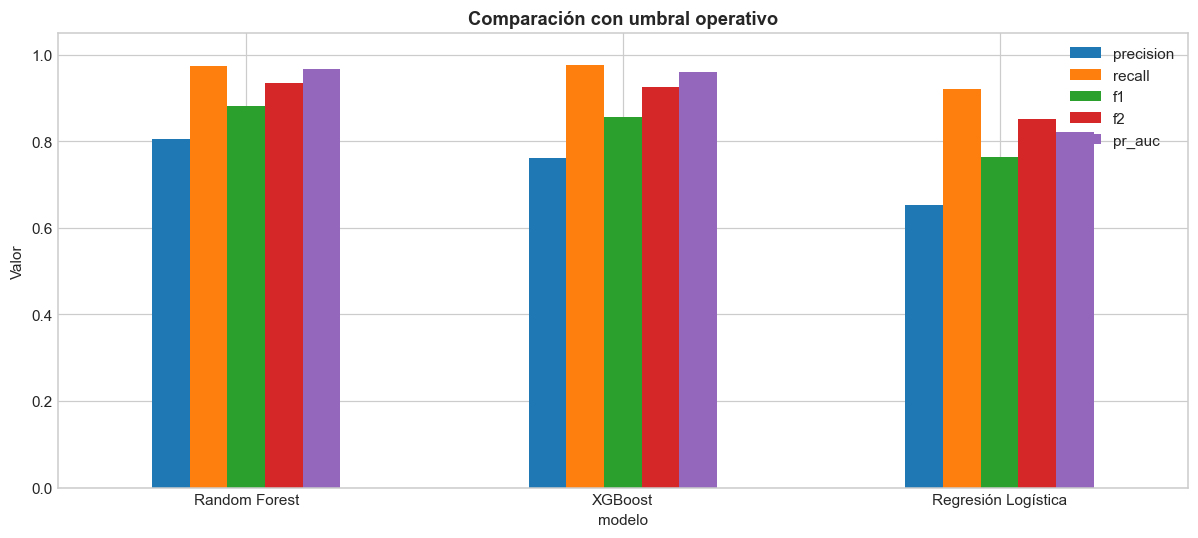

In [7]:
baseline_accuracy = 1 - prevalencia_test
comparacion = metricas_operativas.sort_values(["pr_auc", "f2"], ascending=False).reset_index(drop=True)
display(comparacion[columnas_metricas])

mejor_modelo = comparacion.loc[0, "modelo"]
print(f"Accuracy de la línea base mayoritaria: {baseline_accuracy:.4f}")
print(f"Mejor modelo por PR-AUC y F2: {mejor_modelo}")

fig, ax = plt.subplots(figsize=(11, 5))
metricas_grafico = comparacion.set_index("modelo")[["precision", "recall", "f1", "f2", "pr_auc"]]
metricas_grafico.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor")
ax.set_title("Comparación con umbral operativo")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_comparacion_modelos.png", dpi=180, bbox_inches="tight")
plt.show()


**Resultado:** Random Forest presenta el mejor equilibrio global. Con el umbral operativo obtiene aproximadamente `PR-AUC=0.967`, `recall=0.975`, `precision=0.804` y `F2=0.935`. En 180,000 píxeles de prueba identifica 1,760 positivos, deja 46 falsos negativos y produce 428 falsos positivos.

XGBoost logra el *recall* más alto (`0.977`) y deja solo 42 falsos negativos, pero produce 549 falsas alertas y obtiene menor PR-AUC/F2 que Random Forest. La regresión logística ofrece una referencia interpretable; con umbral 0.5 alcanza un *recall* muy alto, pero a costa de miles de falsas alertas.


## 5.3 Interpretación ambiental de los errores

### Falso positivo: predice presencia elevada donde realmente es baja

Puede activar inspecciones, muestreos, advertencias o restricciones innecesarias. Esto consume recursos, afecta actividades recreativas y puede reducir la confianza pública si las alertas falsas son frecuentes.

### Falso negativo: no detecta una zona con presencia elevada

Es el error ambientalmente más grave: una floración puede permanecer sin vigilancia, retrasar el muestreo de toxinas y exponer a personas, animales y ecosistemas. También impide actuar tempranamente sobre una zona que podría expandirse.

Por lo tanto, se prioriza reducir falsos negativos, pero sin ignorar el costo operativo de miles de falsos positivos. **F2** es la métrica principal de umbral porque pondera el *recall* cuatro veces más que la precisión; **PR-AUC** se usa para comparar la capacidad de ranking bajo desbalance.

Random Forest se recomienda para continuar a validación espacial porque combina el mejor F2 y PR-AUC con `recall≈0.975`. Si la política ambiental exigiera sensibilidad casi absoluta, podría reducirse todavía más su umbral, aceptando más falsas alarmas; esa decisión debe fijarse con los gestores y costos reales.


## 5.4 Comprobación de coherencia y límites

Los resultados son matemáticamente coherentes: todos los modelos superan ampliamente la PR-AUC aleatoria (~1 %), las matrices concuerdan con las métricas y el test es común. El desempeño alto es plausible porque B07/B8A captan señal de biomasa y porque el split aleatorio coloca píxeles vecinos de una misma escena en entrenamiento y prueba.

Sin embargo, **no debe interpretarse como capacidad demostrada para generalizar a zonas o fechas nuevas**. La autocorrelación espacial hace optimista esta evaluación convencional. También hay solo 37 positivos de Atitlán en el test, por lo que sus métricas específicas son inestables. La conclusión final deberá esperar la validación por bloques espaciales y temporal solicitada en los ejercicios posteriores.



In [8]:
filas_lago = []
for lago, grupo in predicciones_test.groupby("lago", observed=True):
    for modelo, slug in slugs.items():
        prob = grupo[f"prob_{slug}"].to_numpy()
        umbral = manifest_modelos["umbrales_operativos"][modelo]
        pred = prob >= umbral
        filas_lago.append({
            "lago": lago,
            "modelo": modelo,
            "n_test": len(grupo),
            "positivos_reales": int(grupo["alta_cyano"].sum()),
            "precision": precision_score(grupo["alta_cyano"], pred, zero_division=0),
            "recall": recall_score(grupo["alta_cyano"], pred, zero_division=0),
            "pr_auc": average_precision_score(grupo["alta_cyano"], prob),
        })

metricas_por_lago = pd.DataFrame(filas_lago)
display(metricas_por_lago)
metricas_por_lago.to_csv(OUTPUT_DIR / "09_metricas_modelos_por_lago.csv", index=False)


,lago,modelo,n_test,positivos_reales,precision,recall,pr_auc
0,amatitlan,Regresión Logística,19765,1769,0.681135,0.922555,0.850214
1,amatitlan,Random Forest,19765,1769,0.807190,0.977388,0.969067
2,amatitlan,XGBoost,19765,1769,0.772180,0.979084,0.962073
3,atitlan,Regresión Logística,160235,37,0.201342,0.810811,0.326826
4,atitlan,Random Forest,160235,37,0.673913,0.837838,0.760961
5,atitlan,XGBoost,160235,37,0.457143,0.864865,0.658953


# 6. Validación espacial

## 6.1 Cuadrícula espacial de 1 km × 1 km

Antes de usar bloques espaciales para dividir entrenamiento/prueba, se construye una cuadrícula regular de 1 km × 1 km sobre cada lago y se evalúa si ese tamaño produce suficientes bloques con observaciones válidas, sin eso, un bloque de prueba podría quedar vacío o sin ningún positivo, haciendo la evaluación inútil.

**Reproyección:** no es necesaria, `x_utm`/`y_utm` ya están en EPSG:32615 (WGS 84 / UTM zona 15N) desde el pipeline de preparación (`CRS_ANALISIS`), que es exactamente el sistema pedido.

Se calcula el bloque de cada píxel como `floor(x_utm / 1000)`, `floor(y_utm / 1000)`, y se cuenta, **por cada una de las 22 escenas (lago, fecha)**, cuántas observaciones `alta_cyano=0` y `alta_cyano=1` caen en cada bloque.

In [9]:
TAMANO_M = 1000.0  # 1 km

DATASET_DIR = resultado["dataset_dir"]
columnas_bloque = ["x_utm", "y_utm", "alta_cyano"]

por_escena = {}
filas_resumen = []
for archivo in sorted(DATASET_DIR.glob("lago=*/fecha=*/observaciones.parquet")):
    lago_escena = archivo.parent.parent.name.split("=", 1)[1]
    fecha_escena = archivo.parent.name.split("=", 1)[1]
    datos_escena = pd.read_parquet(archivo, columns=columnas_bloque)
    datos_escena["bloque_x"] = np.floor(datos_escena["x_utm"] / TAMANO_M).astype("int64")
    datos_escena["bloque_y"] = np.floor(datos_escena["y_utm"] / TAMANO_M).astype("int64")
    agrupado = (
        datos_escena.groupby(["bloque_x", "bloque_y"])["alta_cyano"]
        .agg(n_total="count", n_positivos="sum")
        .reset_index()
    )
    agrupado["n_negativos"] = agrupado["n_total"] - agrupado["n_positivos"]
    por_escena[(lago_escena, fecha_escena)] = agrupado
    filas_resumen.append({
        "lago": lago_escena,
        "fecha": fecha_escena,
        "n_bloques": len(agrupado),
        "bloques_con_positivos": int((agrupado["n_positivos"] > 0).sum()),
        "bloques_menos_10_obs": int((agrupado["n_total"] < 10).sum()),
        "obs_totales": int(agrupado["n_total"].sum()),
        "positivos_totales": int(agrupado["n_positivos"].sum()),
    })

resumen_bloques_1km = pd.DataFrame(filas_resumen)
display(resumen_bloques_1km)
resumen_bloques_1km.to_csv(OUTPUT_DIR / "10_resumen_bloques_1km_por_escena.csv", index=False)


,lago,fecha,n_bloques,bloques_con_positivos,bloques_menos_10_obs,obs_totales,positivos_totales
0,amatitlan,2025-01-28,44,3,6,141852,34
1,amatitlan,2025-04-15,38,15,0,144251,387
2,amatitlan,2025-04-28,38,17,0,144700,6393
3,amatitlan,2025-11-24,41,7,3,143545,2564
4,amatitlan,2026-01-08,44,18,6,146461,8661
5,amatitlan,2026-02-02,42,1,4,145437,27
6,amatitlan,2026-02-07,22,1,2,65188,1
7,amatitlan,2026-03-29,38,13,0,146330,9676
8,amatitlan,2026-04-13,38,22,0,147070,2062
9,amatitlan,2026-04-28,38,19,2,139628,43927


**Interpretación.** Con bloques de 1 km, Atitlán, al ser el lago más grande, produce entre ~160 y ~210 bloques por escena, pero muchos concentran cero o muy pocos positivos (la prevalencia de `alta_cyano=1` en Atitlán es extremadamente baja). Amatitlán produce muchos menos bloques por escena (~22–44), pero con una fracción bastante mayor de bloques con al menos un positivo, y esa fracción crece con el tiempo, consistente con el aumento de floraciones ya visto en las secciones 1.5, 2.3 y en los antecedentes del Ejercicio 2.

Esto ya anticipa el problema central de la validación espacial: si se deja un bloque completo fuera como prueba, en Atitlán es muy probable que ese bloque no tenga **ningún** positivo, dejando el recall de esa partición indefinido. Antes de fijar el tamaño de bloque para la validación, conviene mirar esto escena por escena.

### Mapas por escena, Atitlán

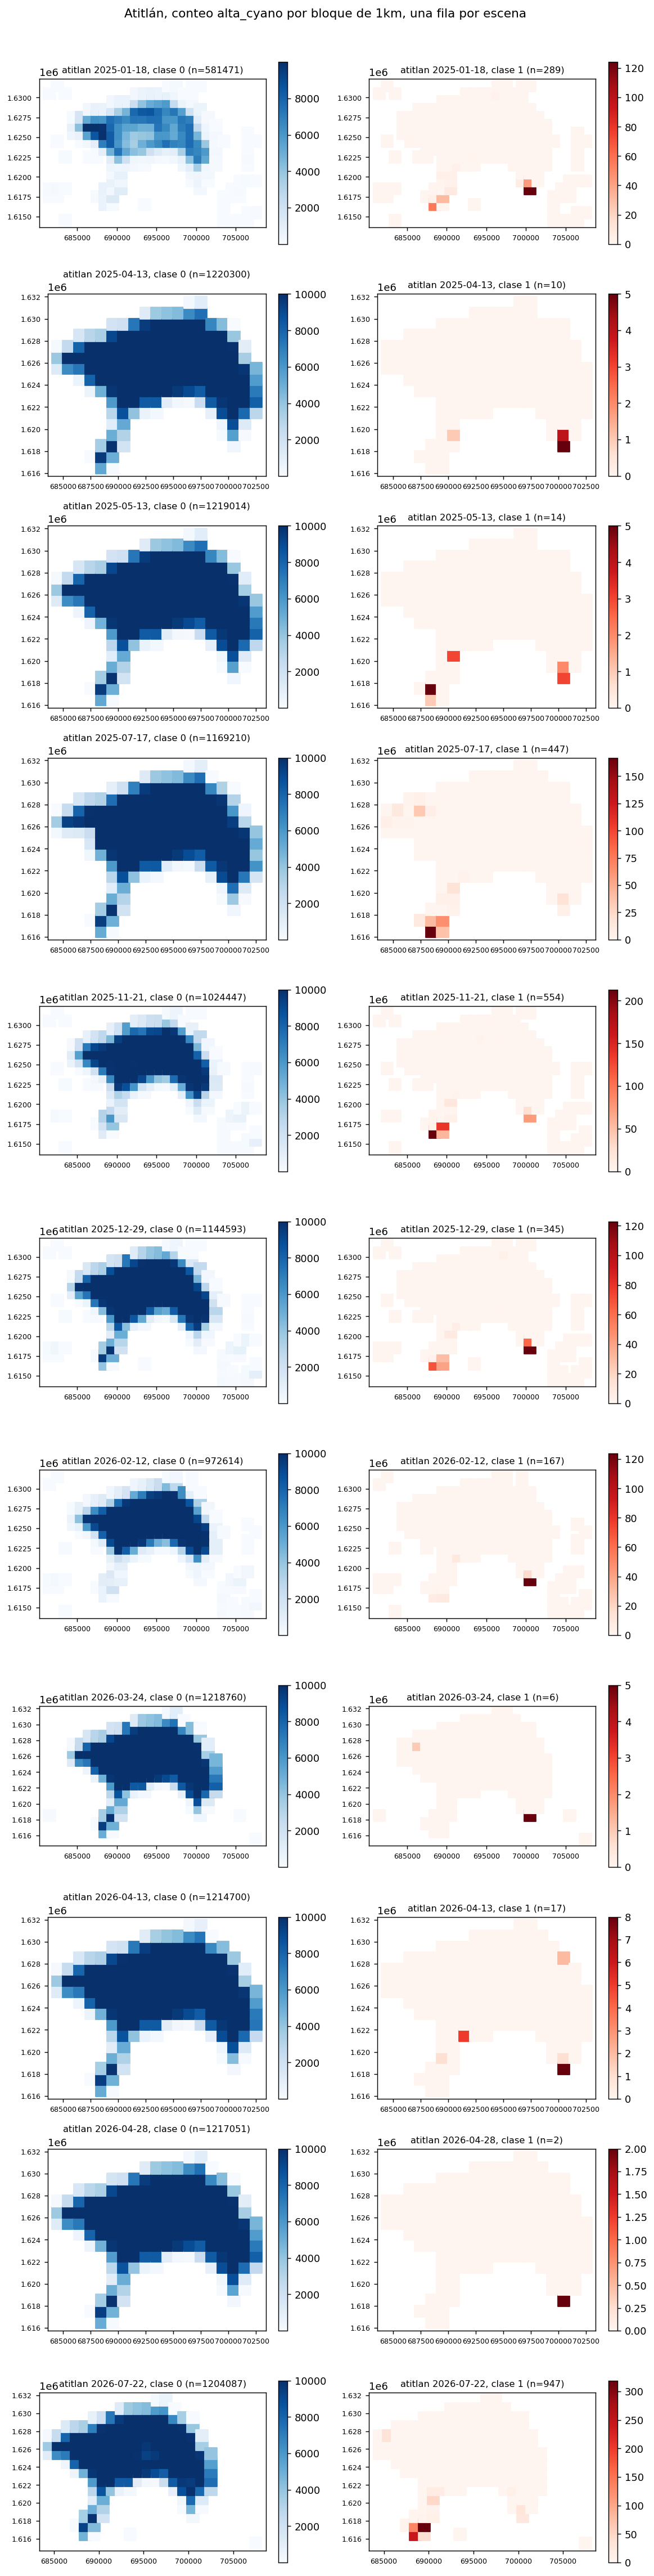

In [10]:
fechas_atitlan = sorted(f for (l, f) in por_escena if l == "atitlan")
fig, axes = plt.subplots(len(fechas_atitlan), 2, figsize=(9, 3.2 * len(fechas_atitlan)))
for fila, fecha_escena in enumerate(fechas_atitlan):
    agrupado = por_escena[("atitlan", fecha_escena)]
    cx = (agrupado["bloque_x"] + 0.5) * TAMANO_M
    cy = (agrupado["bloque_y"] + 0.5) * TAMANO_M

    ax0 = axes[fila, 0]
    sc0 = ax0.scatter(cx, cy, c=agrupado["n_negativos"], cmap="Blues", s=140, marker="s")
    ax0.set_title(f"atitlan {fecha_escena}, clase 0 (n={int(agrupado['n_negativos'].sum())})", fontsize=9)
    ax0.set_aspect("equal")
    ax0.tick_params(labelsize=7)
    fig.colorbar(sc0, ax=ax0, fraction=0.046)

    ax1 = axes[fila, 1]
    sc1 = ax1.scatter(cx, cy, c=agrupado["n_positivos"], cmap="Reds", s=140, marker="s")
    ax1.set_title(f"atitlan {fecha_escena}, clase 1 (n={int(agrupado['n_positivos'].sum())})", fontsize=9)
    ax1.set_aspect("equal")
    ax1.tick_params(labelsize=7)
    fig.colorbar(sc1, ax=ax1, fraction=0.046)

fig.suptitle("Atitlán, conteo alta_cyano por bloque de 1km, una fila por escena", y=1.001)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "11_cuadricula_1km_por_escena_atitlan.png", dpi=130, bbox_inches="tight")
plt.show()


### Mapas por escena, Amatitlán

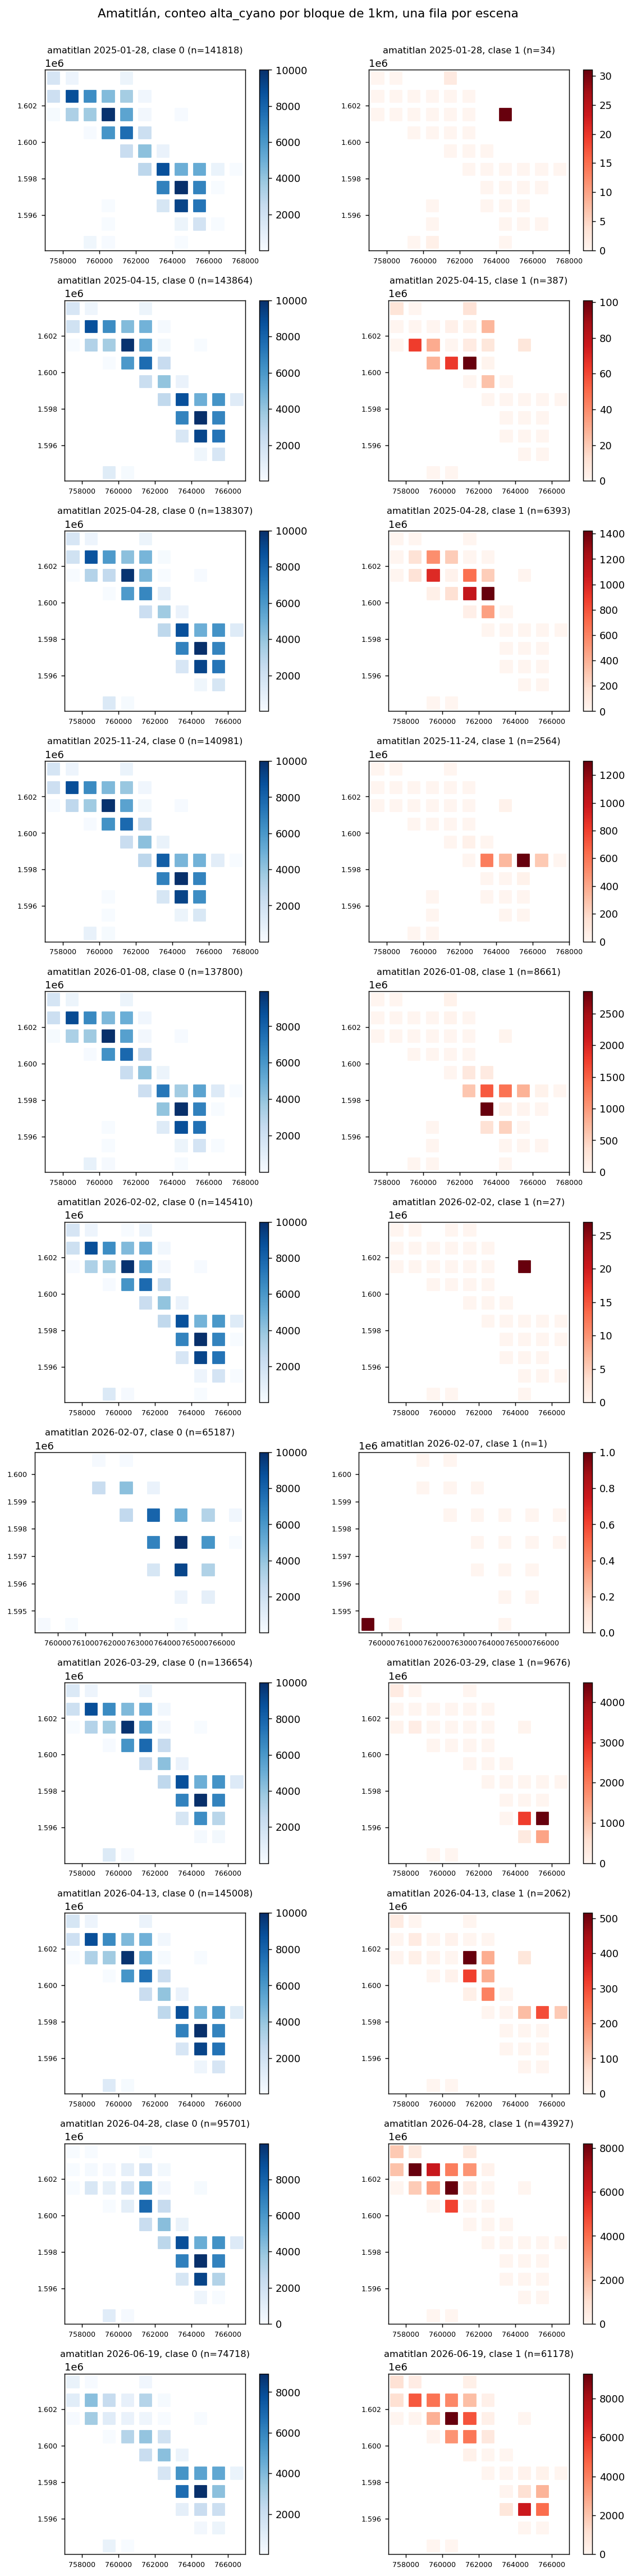

In [11]:
fechas_amatitlan = sorted(f for (l, f) in por_escena if l == "amatitlan")
fig, axes = plt.subplots(len(fechas_amatitlan), 2, figsize=(9, 3.2 * len(fechas_amatitlan)))
for fila, fecha_escena in enumerate(fechas_amatitlan):
    agrupado = por_escena[("amatitlan", fecha_escena)]
    cx = (agrupado["bloque_x"] + 0.5) * TAMANO_M
    cy = (agrupado["bloque_y"] + 0.5) * TAMANO_M

    ax0 = axes[fila, 0]
    sc0 = ax0.scatter(cx, cy, c=agrupado["n_negativos"], cmap="Blues", s=140, marker="s")
    ax0.set_title(f"amatitlan {fecha_escena}, clase 0 (n={int(agrupado['n_negativos'].sum())})", fontsize=9)
    ax0.set_aspect("equal")
    ax0.tick_params(labelsize=7)
    fig.colorbar(sc0, ax=ax0, fraction=0.046)

    ax1 = axes[fila, 1]
    sc1 = ax1.scatter(cx, cy, c=agrupado["n_positivos"], cmap="Reds", s=140, marker="s")
    ax1.set_title(f"amatitlan {fecha_escena}, clase 1 (n={int(agrupado['n_positivos'].sum())})", fontsize=9)
    ax1.set_aspect("equal")
    ax1.tick_params(labelsize=7)
    fig.colorbar(sc1, ax=ax1, fraction=0.046)

fig.suptitle("Amatitlán, conteo alta_cyano por bloque de 1km, una fila por escena", y=1.001)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "12_cuadricula_1km_por_escena_amatitlan.png", dpi=130, bbox_inches="tight")
plt.show()


## 6.2 Asignación de observaciones a bloques espaciales y mapa

A diferencia de la sección anterior (una cuadrícula distinta por cada escena, solo para diagnóstico), aquí se construye **una única cuadrícula de 1 km por lago**, fija, y se asigna cada una de las 13,689,403 observaciones, de las 22 fechas juntas, al bloque que le corresponde según su `x_utm`/`y_utm`. Esta es la asignación de bloques que se usará en 6.3 como grupo para la validación espacial.

Por cada bloque se reporta cuántas observaciones son `alta_cyano=0` y cuántas son `alta_cyano=1`.

In [12]:
columnas_bloque_lago = ["x_utm", "y_utm", "alta_cyano"]
partes_lago = []
for archivo in sorted(DATASET_DIR.glob("lago=*/fecha=*/observaciones.parquet")):
    lago_archivo = archivo.parent.parent.name.split("=", 1)[1]
    parte = pd.read_parquet(archivo, columns=columnas_bloque_lago)
    parte["lago"] = lago_archivo
    partes_lago.append(parte)
datos_bloques = pd.concat(partes_lago, ignore_index=True)

datos_bloques["bloque_x"] = np.floor(datos_bloques["x_utm"] / TAMANO_M).astype("int64")
datos_bloques["bloque_y"] = np.floor(datos_bloques["y_utm"] / TAMANO_M).astype("int64")
datos_bloques["bloque_id"] = (
    datos_bloques["lago"] + "_"
    + datos_bloques["bloque_x"].astype(str) + "_"
    + datos_bloques["bloque_y"].astype(str)
)

print(f"Observaciones asignadas a bloques: {len(datos_bloques):,}")
print(f"Bloques distintos (lago + celda): {datos_bloques['bloque_id'].nunique()}")

bloques_1km = (
    datos_bloques.groupby(["lago", "bloque_id", "bloque_x", "bloque_y"], observed=True)["alta_cyano"]
    .agg(n_alta_cyano_0=lambda s: int((s == 0).sum()), n_alta_cyano_1=lambda s: int((s == 1).sum()))
    .reset_index()
)
bloques_1km["n_total"] = bloques_1km["n_alta_cyano_0"] + bloques_1km["n_alta_cyano_1"]
bloques_1km = bloques_1km.sort_values(["lago", "n_total"], ascending=[True, False]).reset_index(drop=True)

print(f"\nTotal de bloques: {len(bloques_1km)} "
      f"({(bloques_1km['lago']=='atitlan').sum()} Atitlán, "
      f"{(bloques_1km['lago']=='amatitlan').sum()} Amatitlán)")
display(bloques_1km[["lago", "bloque_id", "n_alta_cyano_0", "n_alta_cyano_1", "n_total"]])

bloques_1km.to_csv(OUTPUT_DIR / "13_bloques_1km_por_lago_conteo_clases.csv", index=False)


Observaciones asignadas a bloques: 13,689,403


Bloques distintos (lago + celda): 256



Total de bloques: 256 (211 Atitlán, 45 Amatitlán)


,lago,bloque_id,n_alta_cyano_0,n_alta_cyano_1,n_total
0,amatitlan,amatitlan_764_1597,108809,1191,110000
1,amatitlan,amatitlan_764_1596,90884,10234,101118
2,amatitlan,amatitlan_760_1601,81218,17499,98717
3,amatitlan,amatitlan_763_1598,90305,2131,92436
4,amatitlan,amatitlan_758_1602,74453,13459,87912
...,...,...,...,...,...
251,atitlan,atitlan_706_1624,9,0,9
252,atitlan,atitlan_699_1630,8,0,8
253,atitlan,atitlan_693_1616,7,0,7
254,atitlan,atitlan_706_1625,5,0,5


### Mapa de los bloques generados (1 km, agregando las 22 fechas)

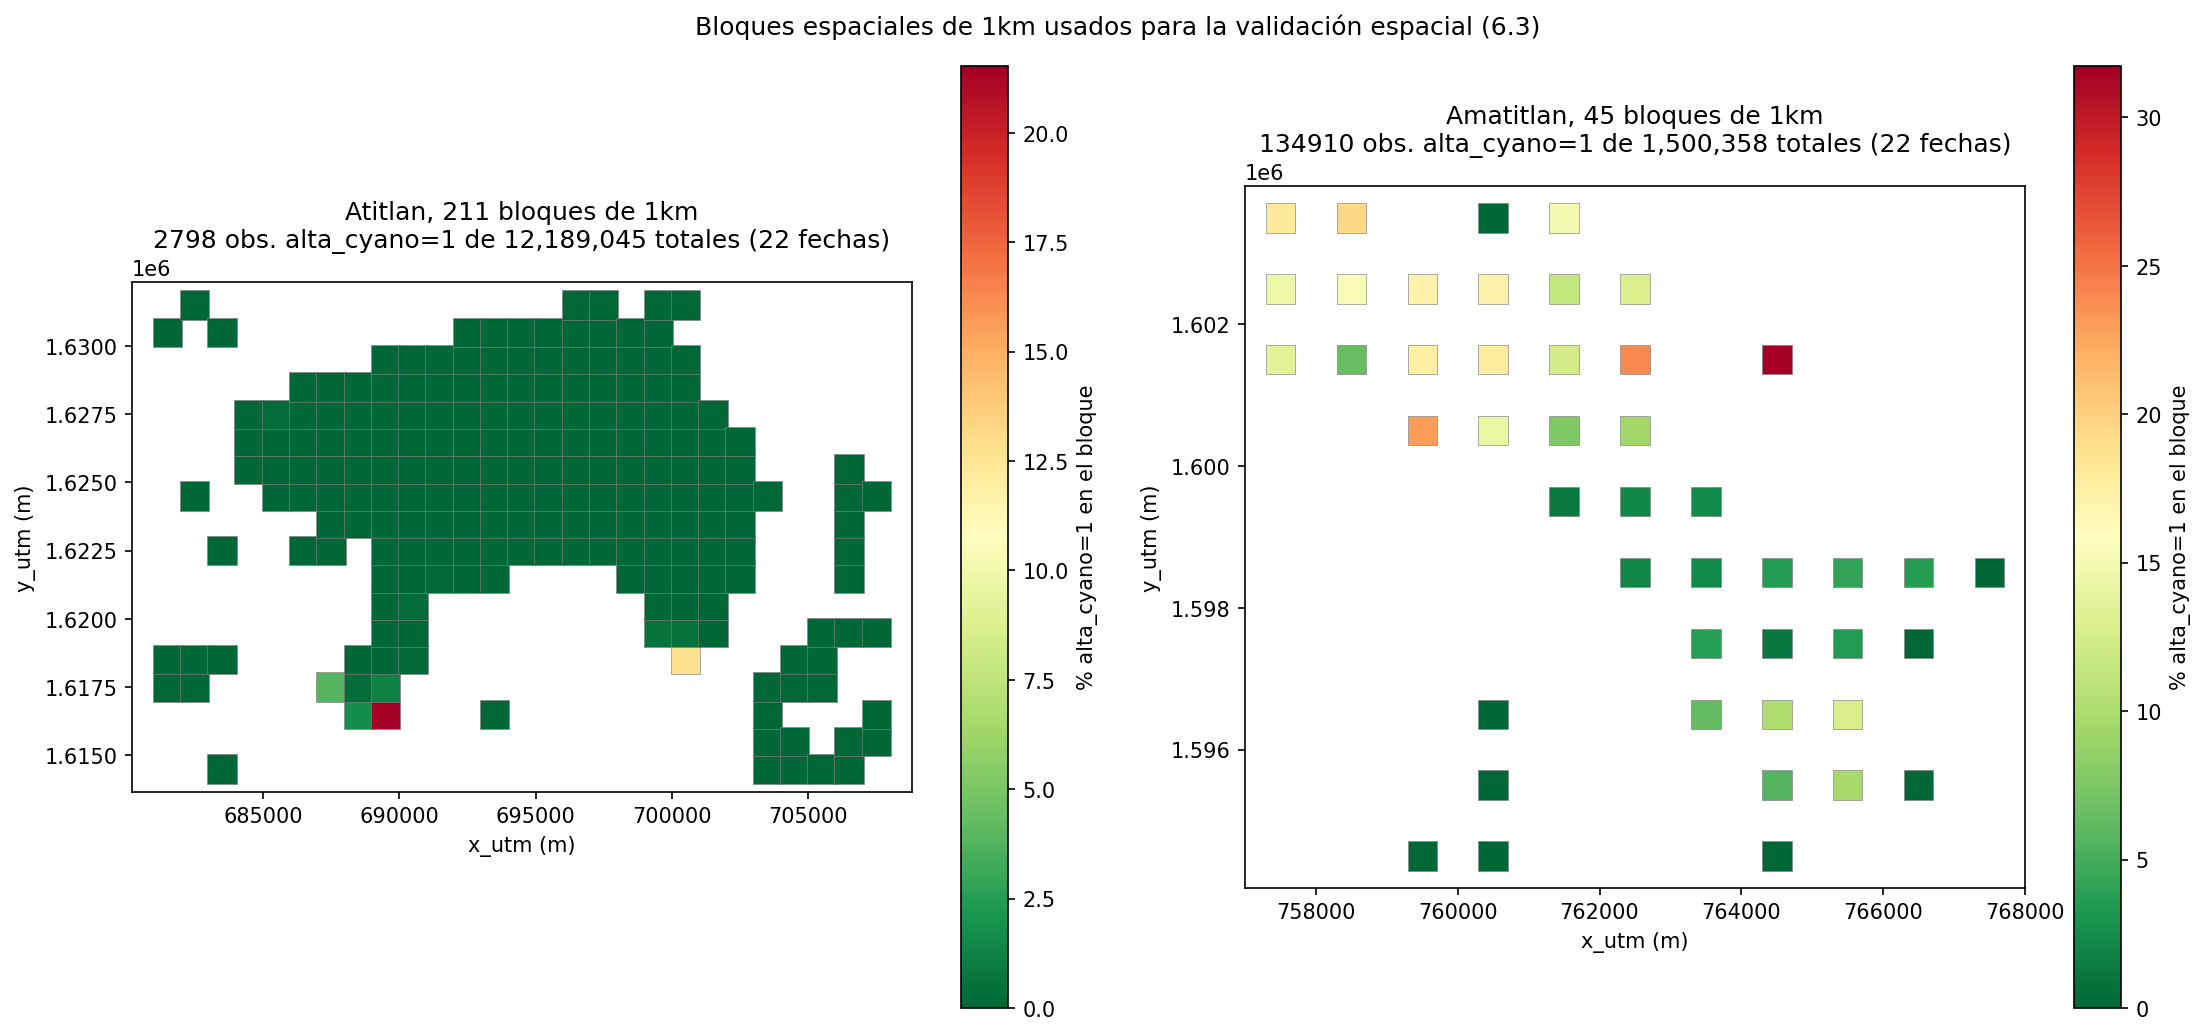

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, lago_mapa in zip(axes, ["atitlan", "amatitlan"]):
    sub_bloques = bloques_1km.loc[bloques_1km["lago"] == lago_mapa]
    cx = (sub_bloques["bloque_x"] + 0.5) * TAMANO_M
    cy = (sub_bloques["bloque_y"] + 0.5) * TAMANO_M
    tasa_positivos = sub_bloques["n_alta_cyano_1"] / sub_bloques["n_total"] * 100
    sc = ax.scatter(cx, cy, c=tasa_positivos, cmap="RdYlGn_r", s=200, marker="s",
                     vmin=0, vmax=max(tasa_positivos.max(), 1), edgecolors="grey", linewidths=0.3)
    ax.set_title(f"{lago_mapa.capitalize()}, {len(sub_bloques)} bloques de 1km\n"
                 f"{int(sub_bloques['n_alta_cyano_1'].sum())} obs. alta_cyano=1 de "
                 f"{int(sub_bloques['n_total'].sum()):,} totales (22 fechas)")
    ax.set_xlabel("x_utm (m)")
    ax.set_ylabel("y_utm (m)")
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, label="% alta_cyano=1 en el bloque")
fig.suptitle("Bloques espaciales de 1km usados para la validación espacial (6.3)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "14_mapa_bloques_1km_por_lago.png", dpi=150, bbox_inches="tight")
plt.show()


## 6.3 Validación espacial: `StratifiedGroupKFold` por bloque

Se reutiliza exactamente la misma muestra de modelado de 600,000 observaciones (`muestra_modelado.parquet`) que usó la validación aleatoria de la sección 4, para que la comparación de 6.5 aísle únicamente el efecto del esquema de partición, no cambios en el tamaño de muestra, los predictores o los hiperparámetros.

Se usa `StratifiedGroupKFold` (5 particiones) en vez de `GroupKFold` simple: el grupo es `bloque_id` (celda de 1 km × lago, igual que en 6.2), así que ninguna observación de un mismo bloque queda repartida entre entrenamiento y prueba dentro de un fold, pero además intenta balancear la clase positiva entre folds tanto como la restricción de grupo lo permite. Esto es necesario porque, dentro de esta muestra, **189 de los 243 bloques presentes no contienen ningún positivo**: con un `GroupKFold` sin estratificar, algún fold podría quedar con casi ningún positivo por pura mala suerte en el sorteo de bloques.

Para aislar el efecto del esquema de validación, cada modelo se reentrena en cada fold **con los mismos hiperparámetros y el mismo umbral operativo** ya seleccionados en la sección 4.3 (no se vuelve a buscar hiperparámetros ni umbral por fold).

In [14]:
from modelar_ml import _estimador, metricas_binarias
from sklearn.model_selection import StratifiedGroupKFold

muestra_modelado_completa = pd.read_parquet(resultado_modelos["muestra"])
muestra_modelado_completa["bloque_x"] = np.floor(muestra_modelado_completa["x_utm"] / TAMANO_M).astype("int64")
muestra_modelado_completa["bloque_y"] = np.floor(muestra_modelado_completa["y_utm"] / TAMANO_M).astype("int64")
muestra_modelado_completa["bloque_id"] = (
    muestra_modelado_completa["lago"].astype(str) + "_"
    + muestra_modelado_completa["bloque_x"].astype(str) + "_"
    + muestra_modelado_completa["bloque_y"].astype(str)
)

n_bloques_muestra = muestra_modelado_completa["bloque_id"].nunique()
pos_por_bloque_muestra = muestra_modelado_completa.groupby("bloque_id")["alta_cyano"].sum()
print(f"Bloques distintos en la muestra de modelado: {n_bloques_muestra}")
print(f"Bloques sin ningún positivo: {(pos_por_bloque_muestra == 0).sum()} de {n_bloques_muestra}")

X_espacial = muestra_modelado_completa[PREDICTORAS]
y_espacial = muestra_modelado_completa["alta_cyano"].astype("uint8")
grupos_espacial = muestra_modelado_completa["bloque_id"]

N_FOLDS = 5
skf_grupo = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf_grupo.split(X_espacial, y_espacial, groups=grupos_espacial))

resumen_folds = pd.DataFrame([
    {
        "fold": i + 1,
        "n_train": len(idx_tr),
        "n_test": len(idx_te),
        "positivos_train": int(y_espacial.iloc[idx_tr].sum()),
        "positivos_test": int(y_espacial.iloc[idx_te].sum()),
        "bloques_test": grupos_espacial.iloc[idx_te].nunique(),
    }
    for i, (idx_tr, idx_te) in enumerate(folds)
])
display(resumen_folds)


Bloques distintos en la muestra de modelado: 243
Bloques sin ningún positivo: 189 de 243


,fold,n_train,n_test,positivos_train,positivos_test,bloques_test
0,1,483451,116549,4113,1906,51
1,2,469241,130759,4835,1184,50
2,3,467410,132590,4930,1089,50
3,4,498627,101373,5137,882,47
4,5,481271,118729,5061,958,45


## 6.4 Reentrenamiento de los modelos con validación espacial

Para cada uno de los 5 folds se reentrena cada modelo (con los hiperparámetros de la sección 4.3) usando los 4 folds restantes y se evalúa en el fold retenido, con el mismo umbral operativo F2 ya elegido en la validación aleatoria.

In [15]:
filas_espacial = []
for nombre, parametros in manifest_modelos["parametros_elegidos"].items():
    umbral_modelo = manifest_modelos["umbrales_operativos"][nombre]
    for i, (idx_tr, idx_te) in enumerate(folds, start=1):
        estimador = _estimador(nombre, parametros)
        estimador.fit(X_espacial.iloc[idx_tr], y_espacial.iloc[idx_tr])
        prob_fold = estimador.predict_proba(X_espacial.iloc[idx_te])[:, 1]
        m05, _ = metricas_binarias(y_espacial.iloc[idx_te], prob_fold, 0.5)
        mop, _ = metricas_binarias(y_espacial.iloc[idx_te], prob_fold, umbral_modelo)
        for m, tipo in [(m05, "0.5"), (mop, "operativo_F2")]:
            m.update({"modelo": nombre, "fold": i, "tipo_umbral": tipo})
            filas_espacial.append(m)
        print(f"{nombre} fold {i}/{N_FOLDS}: PR-AUC={mop['pr_auc']:.4f}, recall={mop['recall']:.4f}")

metricas_espacial_todos = pd.DataFrame(filas_espacial)
metricas_espacial_todos.to_csv(OUTPUT_DIR / "15_metricas_validacion_espacial_por_fold.csv", index=False)

columnas_agregar = ["accuracy", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc", "balanced_accuracy", "specificity"]
metricas_espacial_agg = (
    metricas_espacial_todos.loc[metricas_espacial_todos["tipo_umbral"] == "operativo_F2"]
    .groupby("modelo")[columnas_agregar]
    .agg(["mean", "std"])
)
metricas_espacial_agg.columns = [f"{col}_{stat}" for col, stat in metricas_espacial_agg.columns]
metricas_espacial_agg = metricas_espacial_agg.reset_index()
display(metricas_espacial_agg)
metricas_espacial_agg.to_csv(OUTPUT_DIR / "16_metricas_validacion_espacial_agregado.csv", index=False)


Regresión Logística fold 1/5: PR-AUC=0.8760, recall=0.9601


Regresión Logística fold 2/5: PR-AUC=0.7399, recall=0.8953


Regresión Logística fold 3/5: PR-AUC=0.8575, recall=0.9275


Regresión Logística fold 4/5: PR-AUC=0.8657, recall=0.8980


Regresión Logística fold 5/5: PR-AUC=0.6768, recall=0.8747


...

XGBoost fold 2/5: PR-AUC=0.9003, recall=0.9215


XGBoost fold 3/5: PR-AUC=0.9256, recall=0.8944


XGBoost fold 4/5: PR-AUC=0.9457, recall=0.9433


XGBoost fold 5/5: PR-AUC=0.8335, recall=0.8622


,modelo,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f2_mean,f2_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,specificity_mean,specificity_std
0,Random Forest,0.995868,0.001383,0.757444,0.086455,0.831709,0.112637,0.791931,0.094559,0.815069,0.104008,0.997722,0.000652,0.872230,0.051261,0.914544,0.056375,0.997379,0.000903
1,Regresión Logística,0.994190,0.001740,0.647406,0.085330,0.911110,0.033228,0.754974,0.067157,0.840708,0.047858,0.997303,0.000500,0.803192,0.089633,0.953033,0.016486,0.994956,0.001742
2,XGBoost,0.996119,0.000966,0.744857,0.047810,0.916405,0.039141,0.821420,0.041661,0.875777,0.039022,0.998828,0.000322,0.901103,0.042315,0.956628,0.019405,0.996851,0.000958


## 6.5 Comparación: validación aleatoria vs. validación espacial

Se compara, con umbral operativo F2, la evaluación de la sección 5 (una sola división aleatoria 70/30) contra el promedio de los 5 folds de validación espacial (6.4). Si la validación espacial da métricas notablemente más bajas, confirma la sospecha ya planteada en 5.4: el desempeño de la validación aleatoria era optimista por autocorrelación espacial entre train y test.

,modelo,precision,recall,f1,f2,pr_auc,roc_auc,validacion
0,Random Forest,0.8044,0.9745,0.8813,0.9350,0.9667,0.9996,Aleatoria (70/30)
1,Random Forest,0.7574,0.8317,0.7919,0.8151,0.8722,0.9977,Espacial (media 5-fold)
2,Regresión Logística,0.6530,0.9203,0.7640,0.8507,0.8213,0.9978,Aleatoria (70/30)
3,Regresión Logística,0.6474,0.9111,0.7550,0.8407,0.8032,0.9973,Espacial (media 5-fold)
4,XGBoost,0.7626,0.9767,0.8565,0.9248,0.9592,0.9996,Aleatoria (70/30)
5,XGBoost,0.7449,0.9164,0.8214,0.8758,0.9011,0.9988,Espacial (media 5-fold)


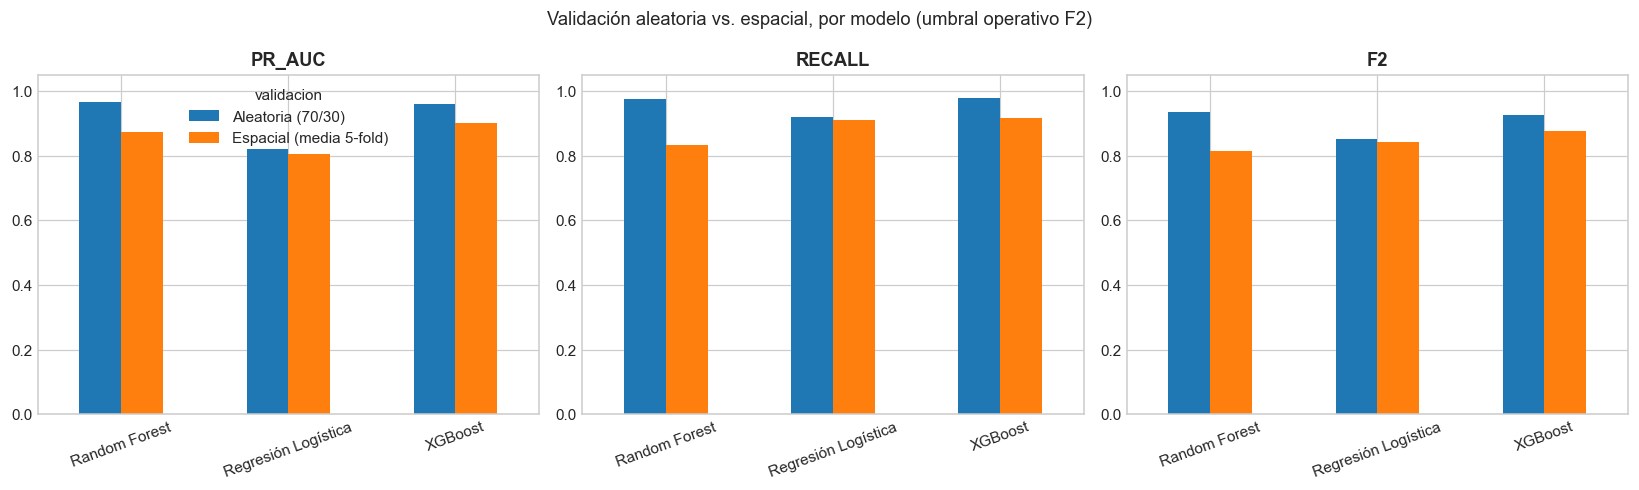

In [16]:
comparacion_val = metricas_operativas[["modelo", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc"]].copy()
comparacion_val["validacion"] = "Aleatoria (70/30)"

espacial_para_tabla = metricas_espacial_agg.rename(columns={
    "precision_mean": "precision", "recall_mean": "recall", "f1_mean": "f1",
    "f2_mean": "f2", "pr_auc_mean": "pr_auc", "roc_auc_mean": "roc_auc",
})[["modelo", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc"]].copy()
espacial_para_tabla["validacion"] = "Espacial (media 5-fold)"

tabla_comparativa = pd.concat([comparacion_val, espacial_para_tabla], ignore_index=True)
tabla_comparativa = tabla_comparativa.sort_values(["modelo", "validacion"]).reset_index(drop=True)
display(tabla_comparativa.style.format({c: "{:.4f}" for c in ["precision","recall","f1","f2","pr_auc","roc_auc"]}))
tabla_comparativa.to_csv(OUTPUT_DIR / "17_comparacion_validacion_aleatoria_vs_espacial.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metrica in zip(axes, ["pr_auc", "recall", "f2"]):
    pivote = tabla_comparativa.pivot(index="modelo", columns="validacion", values=metrica)
    pivote.plot(kind="bar", ax=ax, legend=(metrica == "pr_auc"))
    ax.set_title(metrica.upper())
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.set_xlabel("")
fig.suptitle("Validación aleatoria vs. espacial, por modelo (umbral operativo F2)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "18_comparacion_aleatoria_vs_espacial.png", dpi=180, bbox_inches="tight")
plt.show()


**Interpretación.** La validación aleatoria era optimista, tal como advertía la sección 5.4, pero no en la misma medida para los tres modelos:

| Modelo | PR-AUC aleatoria → espacial | Recall aleatoria → espacial | F2 aleatoria → espacial |
|---|---|---|---|
| Random Forest | 0.967 → 0.872 (-9.8 pp) | 0.975 → 0.832 (-14.3 pp) | 0.935 → 0.815 (-12.0 pp) |
| XGBoost | 0.959 → 0.901 (-5.8 pp) | 0.977 → 0.916 (-6.0 pp) | 0.925 → 0.876 (-4.9 pp) |
| Regresión Logística | 0.821 → 0.803 (-1.8 pp) | 0.920 → 0.911 (-0.9 pp) | 0.851 → 0.841 (-1.0 pp) |

**Random Forest es el que más se desinfla**, cae de ser el mejor modelo bajo validación aleatoria a quedar por debajo de XGBoost bajo validación espacial. Esto es coherente con que RF, al tener 240 árboles poco restringidos (profundidad 20), tiene más capacidad de memorizar patrones locales específicos de cada píxel/vecindario cuando esos vecinos también están en el set de entrenamiento, justo lo que el split aleatorio permitía y el split por bloque impide. **XGBoost pasa a ser el modelo más robusto y el mejor bajo validación espacial** (PR-AUC=0.901, recall=0.916), con una caída moderada. **La regresión logística es la que menos se degrada** (apenas ~1-2 puntos porcentuales): al ser un modelo lineal con mucha menos capacidad de ajustar detalles locales, nunca pudo aprovechar tanto la fuga espacial en primer lugar, así que tampoco tiene tanto que perder al quitársela.

También vale la pena notar la **variabilidad entre folds** (columnas `_std` de la tabla de 6.4): Random Forest tiene la mayor dispersión (recall_std=0.113, con un fold particularmente malo de recall=0.637), mientras que XGBoost es más estable entre folds (recall_std=0.039). Esto refuerza la recomendación de la sección 5.3: **XGBoost, no Random Forest, es el candidato más defendible para producción**, porque su buen desempeño no depende de que los píxeles de prueba tengan vecinos casi idénticos en entrenamiento, generaliza mejor a zonas geográficas nuevas, que es exactamente el escenario de uso real (monitorear áreas del lago fuera de las 22 escenas ya vistas).

## 6.6 ¿El desempeño aumentó o disminuyó con la validación espacial?

**Disminuyó, para los tres modelos**, al pasar de la validación aleatoria (70/30) a la validación espacial (`StratifiedGroupKFold` por bloque de 1 km, media de 5 folds), con umbral operativo F2:

| Modelo | PR-AUC | Recall | F2 |
|---|---|---|---|
| Random Forest | 0.967 → 0.872 (**-9.8 pp**) | 0.975 → 0.832 (**-14.3 pp**) | 0.935 → 0.815 (**-12.0 pp**) |
| XGBoost | 0.959 → 0.901 (**-5.8 pp**) | 0.977 → 0.916 (**-6.0 pp**) | 0.925 → 0.876 (**-4.9 pp**) |
| Regresión Logística | 0.821 → 0.803 (**-1.8 pp**) | 0.920 → 0.911 (**-0.9 pp**) | 0.851 → 0.841 (**-1.0 pp**) |

**Magnitud:** la caída no es pareja. Random Forest es el más afectado (~10-14 puntos porcentuales), XGBoost tiene una caída moderada (~5-6 puntos), y la regresión logística apenas se mueve (~1-2 puntos). En términos relativos, el recall de Random Forest cae ~14.7%, mientras que el de la regresión logística cae solo ~1.0%.

**Por qué puede ocurrir:** la partición aleatoria 70/30 reparte píxeles individuales al azar, sin respetar su ubicación geográfica. Como los píxeles vecinos dentro de una misma escena están espacialmente autocorrelacionados (comparten condiciones de agua, iluminación y biomasa muy similares), es común que un píxel de entrenamiento y uno de prueba sean casi idénticos y estén a pocos metros de distancia. Eso deja que el modelo "reconozca" el vecindario en lugar de aprender una relación espectral generalizable, y la métrica de prueba queda inflada por esa fuga de información espacial, un problema más grave cuanto más flexible es el modelo: Random Forest, con árboles profundos, es el más capaz de memorizar esas particularidades locales; XGBoost, con árboles más someros y regularización (`learning_rate`, `subsample`, `colsample_bytree`), lo hace en menor medida; y la regresión logística, al ser un modelo lineal global, casi no tiene forma de explotar patrones tan locales, por lo que su evaluación aleatoria ya era una estimación cercana a la real.

**Qué estrategia da una estimación más realista:** la **validación espacial** (`StratifiedGroupKFold` por bloque). Al forzar que todas las observaciones de un mismo bloque de 1 km quedén siempre juntas, o completas en entrenamiento, o completas en prueba, elimina la posibilidad de que un píxel de prueba tenga un vecino casi idéntico en el entrenamiento. Esto reproduce el escenario de uso real del modelo: predecir sobre zonas del lago que nunca ha visto, no sobre píxeles adyacentes a los que ya vio. Por eso las métricas de la sección 6.4-6.5 son la estimación más confiable de la capacidad real de generalización espacial, y explican por qué la sección 5.4 ya advertía que los resultados de la validación aleatoria eran "matemáticamente coherentes" pero "optimistas".

# 7. Generalización entre lagos

## 7.1 Experimento A y 7.2 Experimento B

Se entrena con las observaciones de un lago completo y se evalúa sobre el otro lago completo (nunca visto). Para que la prueba sea real, se usa `PREDICTORAS_SIN_ATAJOS` (`b07`, `b8a`, `sin_dia_anio`, `cos_dia_anio`, `dias_desde_inicio`), sin `lago`, `x_utm`/`y_utm` ni `nubosidad_pct`/`satelite`, porque las coordenadas de Atitlán y Amatitlán no se solapan en absoluto, y dejarlas permitiría que el modelo memorice "dónde está cada lago" en vez de aprender una relación espectral que en principio podría transferirse. Esto ya estaba anticipado en la sección 3.2 ("en generalización entre lagos se retira `lago`").

También se calculan dos referencias de "mismo lago" (70/30 dentro de cada lago, con el mismo conjunto reducido de predictores) para que la comparación de 7.4 sea justa: aísla el efecto de cruzar de lago del efecto de usar menos predictores.

Se reutilizan los hiperparámetros ya elegidos en la sección 4.3 y se evalúa con umbral 0.5 (no hay partición de validación propia para reajustar un umbral operativo en este experimento).

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from modelar_ml import PREDICTORAS_SIN_ATAJOS
from xgboost import XGBClassifier

print("Predictores sin atajos:", PREDICTORAS_SIN_ATAJOS)


def estimador_sin_atajos(nombre, parametros):
    if nombre == "Regresión Logística":
        modelo = LogisticRegression(
            **parametros, class_weight="balanced", solver="lbfgs", max_iter=600, random_state=RANDOM_STATE,
        )
        return Pipeline([("esc", StandardScaler()), ("modelo", modelo)])
    if nombre == "Random Forest":
        modelo = RandomForestClassifier(
            **parametros, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
        )
        return Pipeline([("modelo", modelo)])
    if nombre == "XGBoost":
        modelo = XGBClassifier(
            **parametros, objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            scale_pos_weight=98.7, n_jobs=-1, random_state=RANDOM_STATE,
        )
        return Pipeline([("modelo", modelo)])
    raise KeyError(nombre)


atitlan_df = muestra_modelado_completa.loc[muestra_modelado_completa["lago"] == "atitlan"].reset_index(drop=True)
amatitlan_df = muestra_modelado_completa.loc[muestra_modelado_completa["lago"] == "amatitlan"].reset_index(drop=True)
print(f"Atitlán: {len(atitlan_df):,} obs, {int(atitlan_df['alta_cyano'].sum())} positivos "
      f"({atitlan_df['alta_cyano'].mean()*100:.4f}%)")
print(f"Amatitlán: {len(amatitlan_df):,} obs, {int(amatitlan_df['alta_cyano'].sum())} positivos "
      f"({amatitlan_df['alta_cyano'].mean()*100:.4f}%)")

idx_at_tr, idx_at_te = train_test_split(
    np.arange(len(atitlan_df)), test_size=0.30, random_state=RANDOM_STATE, stratify=atitlan_df["alta_cyano"]
)
idx_am_tr, idx_am_te = train_test_split(
    np.arange(len(amatitlan_df)), test_size=0.30, random_state=RANDOM_STATE, stratify=amatitlan_df["alta_cyano"]
)

escenarios = {
    "7.1 Experimento A: entrena Atitlán, prueba Amatitlán": (
        atitlan_df[PREDICTORAS_SIN_ATAJOS], atitlan_df["alta_cyano"],
        amatitlan_df[PREDICTORAS_SIN_ATAJOS], amatitlan_df["alta_cyano"],
    ),
    "7.2 Experimento B: entrena Amatitlán, prueba Atitlán": (
        amatitlan_df[PREDICTORAS_SIN_ATAJOS], amatitlan_df["alta_cyano"],
        atitlan_df[PREDICTORAS_SIN_ATAJOS], atitlan_df["alta_cyano"],
    ),
    "Referencia: mismo lago (Atitlán 70/30)": (
        atitlan_df.iloc[idx_at_tr][PREDICTORAS_SIN_ATAJOS], atitlan_df.iloc[idx_at_tr]["alta_cyano"],
        atitlan_df.iloc[idx_at_te][PREDICTORAS_SIN_ATAJOS], atitlan_df.iloc[idx_at_te]["alta_cyano"],
    ),
    "Referencia: mismo lago (Amatitlán 70/30)": (
        amatitlan_df.iloc[idx_am_tr][PREDICTORAS_SIN_ATAJOS], amatitlan_df.iloc[idx_am_tr]["alta_cyano"],
        amatitlan_df.iloc[idx_am_te][PREDICTORAS_SIN_ATAJOS], amatitlan_df.iloc[idx_am_te]["alta_cyano"],
    ),
}

filas7 = []
for nombre_escenario, (X_tr, y_tr, X_te, y_te) in escenarios.items():
    for nombre_modelo, parametros in manifest_modelos["parametros_elegidos"].items():
        est = estimador_sin_atajos(nombre_modelo, parametros)
        est.fit(X_tr, y_tr)
        prob = est.predict_proba(X_te)[:, 1]
        m, _ = metricas_binarias(y_te, prob, 0.5)
        m.update({
            "escenario": nombre_escenario, "modelo": nombre_modelo,
            "n_train": len(X_tr), "positivos_train": int(y_tr.sum()),
            "n_test": len(X_te), "positivos_test": int(y_te.sum()),
        })
        filas7.append(m)
        print(f"[{nombre_escenario}] {nombre_modelo}: PR-AUC={m['pr_auc']:.4f}, "
              f"recall={m['recall']:.4f}, precision={m['precision']:.4f}")

tabla7 = pd.DataFrame(filas7)
tabla7.to_csv(OUTPUT_DIR / "19_generalizacion_entre_lagos.csv", index=False)


Predictores sin atajos: ['b07', 'b8a', 'sin_dia_anio', 'cos_dia_anio', 'dias_desde_inicio']
Atitlán: 534,241 obs, 136 positivos (0.0255%)
Amatitlán: 65,759 obs, 5883 positivos (8.9463%)
[7.1 Experimento A: entrena Atitlán, prueba Amatitlán] Regresión Logística: PR-AUC=0.4665, recall=0.6121, precision=0.2569
[7.1 Experimento A: entrena Atitlán, prueba Amatitlán] Random Forest: PR-AUC=0.4260, recall=0.0243, precision=0.8512
[7.1 Experimento A: entrena Atitlán, prueba Amatitlán] XGBoost: PR-AUC=0.2721, recall=0.1243, precision=0.6597
[7.2 Experimento B: entrena Amatitlán, prueba Atitlán] Regresión Logística: PR-AUC=0.3726, recall=0.8162, precision=0.0070
[7.2 Experimento B: entrena Amatitlán, prueba Atitlán] Random Forest: PR-AUC=0.2157, recall=0.7132, precision=0.1173
[7.2 Experimento B: entrena Amatitlán, prueba Atitlán] XGBoost: PR-AUC=0.2953, recall=0.8015, precision=0.0728
[Referencia: mismo lago (Atitlán 70/30)] Regresión Logística: PR-AUC=0.1487, recall=0.9756, precision=0.0352
[Re

## 7.3 Métricas de evaluación de ambos experimentos

,escenario,modelo,n_train,positivos_train,n_test,positivos_test,precision,recall,f1,f2,roc_auc,pr_auc
0,"7.1 Experimento A: entrena Atitlán, prueba Amatitlán",Regresión Logística,534241,136,65759,5883,0.2569,0.6121,0.3619,0.4795,0.7792,0.4665
1,"7.1 Experimento A: entrena Atitlán, prueba Amatitlán",Random Forest,534241,136,65759,5883,0.8512,0.0243,0.0473,0.0302,0.7507,0.4260
2,"7.1 Experimento A: entrena Atitlán, prueba Amatitlán",XGBoost,534241,136,65759,5883,0.6597,0.1243,0.2091,0.1483,0.8075,0.2721
3,"7.2 Experimento B: entrena Amatitlán, prueba Atitlán",Regresión Logística,65759,5883,534241,136,0.0070,0.8162,0.0138,0.0336,0.9682,0.3726
4,"7.2 Experimento B: entrena Amatitlán, prueba Atitlán",Random Forest,65759,5883,534241,136,0.1173,0.7132,0.2015,0.3538,0.9880,0.2157
5,"7.2 Experimento B: entrena Amatitlán, prueba Atitlán",XGBoost,65759,5883,534241,136,0.0728,0.8015,0.1334,0.2669,0.9888,0.2953
6,Referencia: mismo lago (Atitlán 70/30),Regresión Logística,373968,95,160273,41,0.0352,0.9756,0.0680,0.1540,0.9987,0.1487
7,Referencia: mismo lago (Atitlán 70/30),Random Forest,373968,95,160273,41,0.3922,0.4878,0.4348,0.4651,0.9752,0.4895
8,Referencia: mismo lago (Atitlán 70/30),XGBoost,373968,95,160273,41,0.0752,0.9268,0.1392,0.2840,0.9972,0.1429
9,Referencia: mismo lago (Amatitlán 70/30),Regresión Logística,46031,4118,19728,1765,0.6117,0.9416,0.7416,0.8500,0.9798,0.8478


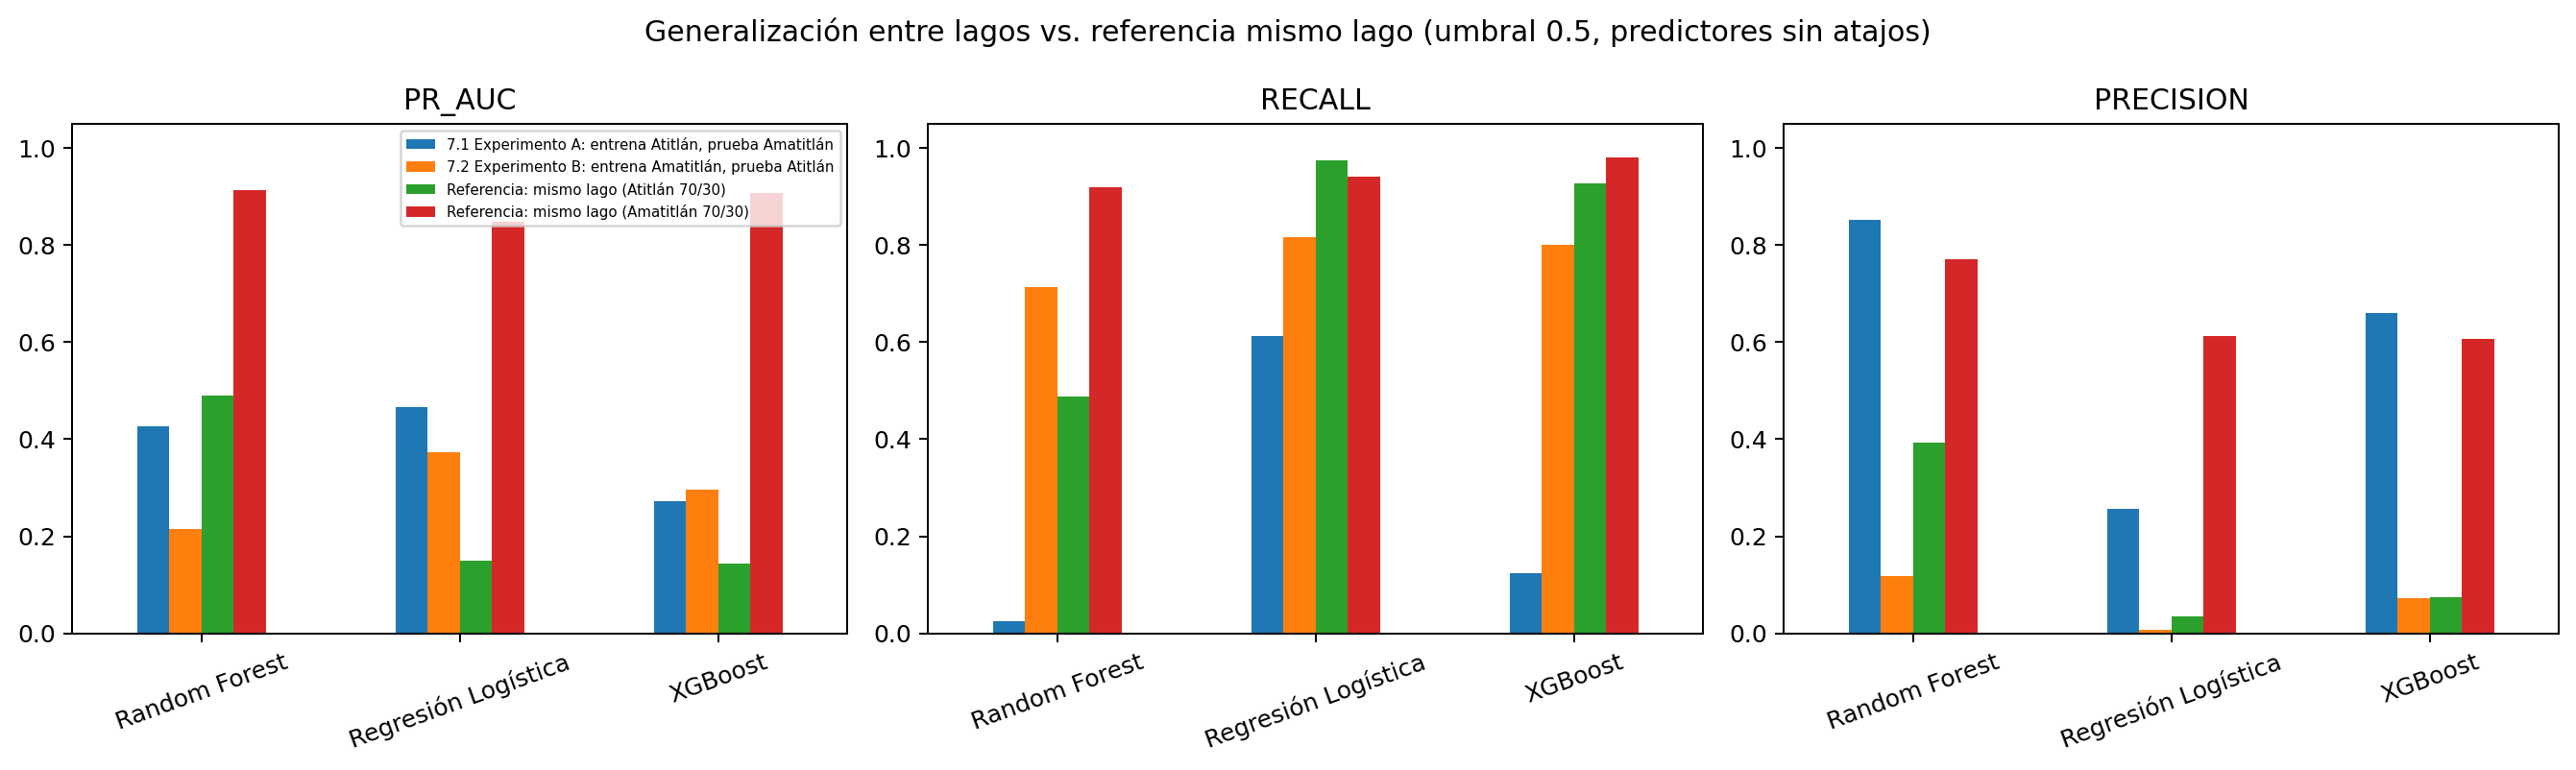

In [18]:
columnas_mostrar = ["escenario", "modelo", "n_train", "positivos_train", "n_test", "positivos_test",
                    "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]
display(tabla7[columnas_mostrar].style.format({c: "{:.4f}" for c in ["precision","recall","f1","f2","roc_auc","pr_auc"]}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
orden_escenarios = list(escenarios.keys())
for ax, metrica in zip(axes, ["pr_auc", "recall", "precision"]):
    pivote = tabla7.pivot(index="modelo", columns="escenario", values=metrica)[orden_escenarios]
    pivote.plot(kind="bar", ax=ax, legend=(metrica == "pr_auc"))
    ax.set_title(metrica.upper())
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.set_xlabel("")
    if metrica == "pr_auc":
        ax.legend(fontsize=6, loc="upper right")
fig.suptitle("Generalización entre lagos vs. referencia mismo lago (umbral 0.5, predictores sin atajos)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "20_generalizacion_entre_lagos.png", dpi=180, bbox_inches="tight")
plt.show()


## 7.4 Comparación contra el mismo lago

**Comparando 7.1 (Atitlán → Amatitlán) contra la referencia propia de Amatitlán (PR-AUC 0.848-0.914 según el modelo):** el cruce de lago cae a PR-AUC 0.27-0.47, muy por debajo. El síntoma más claro es Random Forest, cuyo *recall* colapsa a **2.4%** (solo detecta 143 de 5,883 positivos de Amatitlán) a pesar de tener precisión alta (85%): entrenado con solo 136 positivos de Atitlán, aprende un umbral de decisión demasiado conservador que casi nunca dispara en Amatitlán, donde la señal de cianobacterias es mucho más común e intensa.

**Comparando 7.2 (Amatitlán → Atitlán) contra la referencia propia de Atitlán (PR-AUC 0.14-0.49 según el modelo):** aquí el resultado es más matizado. Para Regresión Logística y XGBoost, el PR-AUC cruzado (0.37 y 0.30) es en realidad **similar o mejor** que la referencia propia de Atitlán (0.15 y 0.14), porque la referencia propia de Atitlán ya es débil de por sí (solo 95 positivos de entrenamiento y 41 de prueba). Pero la precisión cruzada es inutilizable en la práctica (0.7%-11.7%): el modelo entrenado en Amatitlán, acostumbrado a una prevalencia del 9%, dispara alertas con mucha más frecuencia de la que la rarísima prevalencia real de Atitlán (0.026%) puede soportar sin inundarse de falsos positivos.


## 7.5 ¿Un modelo entrenado en un lago puede generalizar adecuadamente al otro?

**No, en ninguna de las dos direcciones, aunque por razones distintas:**

- **Atitlán → Amatitlán:** falla porque el entrenamiento en Atitlán no tiene suficientes ejemplos positivos (136) para aprender qué luce una floración real; el modelo llega a Amatitlán "sin haber visto casi nunca" el fenómeno que debe detectar, y su recall se desploma.
- **Amatitlán → Atitlán:** el modelo sí aprende bien qué es una floración (con 5,883 ejemplos), pero al aplicarlo sobre Atitlán, donde el fenómeno es ~350 veces más raro, genera tantas falsas alertas que la precisión se vuelve inutilizable operativamente, aunque el ranking (PR-AUC/ROC-AUC) no sea peor que la propia referencia débil de Atitlán.

En ambos casos, ningún modelo entrenado en un lago alcanza el desempeño que logra entrenado y evaluado en Amatitlán mismo (PR-AUC ~0.85-0.91), que es el único escenario donde hay suficientes datos positivos para aprender y evaluar con confianza.

## 7.6 ¿Qué características explican las diferencias?

**Prevalencia real muy distinta (la más determinante).** Amatitlán tiene ~9% de observaciones con presencia elevada frente a ~0.026% en Atitlán, una diferencia de ~350 veces. Esto no es un artefacto del muestreo: refleja estados tróficos distintos. Amatitlán, en la cuenca metropolitana de Ciudad de Guatemala, recibe una carga de nutrientes y aguas residuales crónica que ya sostiene una floración establecida (como ya se documentó en la sección 2.4 y en los antecedentes del Ejercicio 2); Atitlán es comparativamente oligotrófico, con floraciones episódicas concentradas en las desembocaduras de ríos, no un estado permanente del lago.

**Diferencias espectrales/ópticas del agua (Case 2 water).** La relación entre reflectancia en `b07`/`b8a` y concentración real de clorofila-a puede no ser idéntica en ambos lagos si difieren en turbidez de fondo, materia orgánica disuelta o sedimentos minerales, todos factores que alteran cómo la luz interactúa con el agua independientemente de la biomasa de cianobacterias. Un modelo entrenado en un lago aprende, en parte, la "huella óptica" específica de ese cuerpo de agua, no solo la relación universal entre banda espectral y clorofila.

**Geografía y morfometría.** Ambos lagos difieren en tamaño, profundidad, altitud y uso del suelo circundante, factores que afectan el tiempo de residencia del agua, la estratificación térmica y la carga de nutrientes, todos moduladores del crecimiento de cianobacterias.

**Un factor metodológico, no solo geográfico.** `scale_pos_weight=98.7` en XGBoost está calibrado para la prevalencia global (~1%) de la muestra combinada, no para la prevalencia real de cada lago por separado (~9% en Amatitlán, ~0.03% en Atitlán). Eso significa que parte de la degradación observada en 7.1/7.2 no es pura incapacidad de generalización geográfica del modelo, sino un desajuste de calibración de peso de clase que un ajuste específico por lago podría mitigar parcialmente, aunque no resolvería el problema de fondo: con solo 136 positivos en Atitlán, ningún ajuste de peso sustituye la falta de ejemplos reales para aprender.